<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/08_langchain_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install -r requirements.txt -q

In [2]:
from dotenv import load_dotenv, find_dotenv

In [3]:
load_dotenv(find_dotenv())

True

In [4]:
# Initializing langchain llm model
from langchain_google_genai import ChatGoogleGenerativeAI

from google.colab import userdata
GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")

model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview", api_key=GOOGLE_API_KEY)
model

ChatGoogleGenerativeAI(profile={'name': 'Gemini 3.1 Flash Lite Preview', 'release_date': '2026-03-03', 'last_updated': '2026-03-03', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-3.1-flash-lite-preview', temperature=1.0, client=<google.genai.client.Client object at 0x7f2016ab1a00>, default_metadata=(), model_kwargs={})

In [5]:
response = model.invoke("Give me the list of G5 nations")
response

AIMessage(content=[{'type': 'text', 'text': 'The **G5** (Group of Five) typically refers to the **five largest economies in the European Union**. These nations hold the most influence within the bloc and often coordinate their positions on economic and political matters.\n\nThe G5 nations are:\n\n1.  **France**\n2.  **Germany**\n3.  **Italy**\n4.  **Spain**\n5.  **United Kingdom** (Note: Although the UK is no longer a member of the European Union, it is historically and still frequently included in this grouping due to its economic size and influence in European affairs.)\n\n***\n\n**Important Note on Terminology:**\nThe term "G5" can sometimes be used in different contexts:\n*   **G5 (Finance):** Historically, this refers to the 1985 meeting of the five largest economies at the time (France, West Germany, Japan, the United States, and the UK) to coordinate exchange rates. This group eventually evolved into the **G7**.\n*   **G5 (Sahel):** There is also a political and military allianc

## Simple chain


In [6]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template("Question: {question}")

parser = StrOutputParser()

chain = prompt | model | parser
chain

ChatPromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='Question: {question}'), additional_kwargs={})])
| ChatGoogleGenerativeAI(profile={'name': 'Gemini 3.1 Flash Lite Preview', 'release_date': '2026-03-03', 'last_updated': '2026-03-03', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-3.1-flash-lite-preview', temperature=1.0, client=<google.genai.cli

In [7]:
response = chain.invoke({"question": "First president of India"})
response

'The first president of India was **Dr. Rajendra Prasad**. He served from 1950 to 1962.'

## Agent

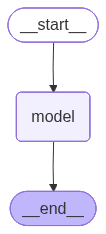

In [8]:
from langchain.agents import create_agent

agent = create_agent(model=model)
agent

In [9]:
from langchain.messages import HumanMessage, SystemMessage, AIMessage

response = agent.invoke({
    "messages": [HumanMessage(content="When India got independence?")]
})
response

{'messages': [HumanMessage(content='When India got independence?', additional_kwargs={}, response_metadata={}, id='11557357-a25e-4f18-b803-4491ff17fe64'),
  AIMessage(content=[{'type': 'text', 'text': 'India gained independence from British rule on **August 15, 1947**.', 'extras': {'signature': 'EjQKMgEMOdbHYneSfIfgOb28aa0r51OVuOaasEeZnIJEjmAv8Mr3DpBAH4QnSIRko6a/wQdP'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ded30-cd5e-7930-b5ec-2979b16482bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 19, 'total_tokens': 25, 'input_token_details': {'cache_read': 0}})]}

In [10]:
## Pretty print the response
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='When India got independence?', additional_kwargs={}, response_metadata={}, id='11557357-a25e-4f18-b803-4491ff17fe64'),
              AIMessage(content=[{'type': 'text', 'text': 'India gained independence from British rule on **August 15, 1947**.', 'extras': {'signature': 'EjQKMgEMOdbHYneSfIfgOb28aa0r51OVuOaasEeZnIJEjmAv8Mr3DpBAH4QnSIRko6a/wQdP'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ded30-cd5e-7930-b5ec-2979b16482bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 19, 'total_tokens': 25, 'input_token_details': {'cache_read': 0}})]}


In [14]:
# Get only the content
print(response['messages'][-1].content[-1]['text'])

India gained independence from British rule on **August 15, 1947**.


In [16]:
## Send list of messages
from langchain_core.messages import AIMessage
messages = [
    HumanMessage(content="Whats the capital of Tamil Nadu"),
    AIMessage(content="Madrasapattinam"),
    HumanMessage(content="Tell me more about it")
]
response = agent.invoke({"messages": messages})
pprint(response)

{'messages': [HumanMessage(content='Whats the capital of Tamil Nadu', additional_kwargs={}, response_metadata={}, id='bded8e30-30ed-4e00-9006-d22b48a138a3'),
              AIMessage(content='Madrasapattinam', additional_kwargs={}, response_metadata={}, id='d3c16c03-c05c-43db-8ded-67d21bf729a1', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='Tell me more about it', additional_kwargs={}, response_metadata={}, id='95f9094b-6368-4c0b-bdce-2b44c0c392c1'),
              AIMessage(content=[{'type': 'text', 'text': 'The city you referred to as **Madrasapattinam** is now officially known as **Chennai**. It is the capital of the Indian state of Tamil Nadu and is often called the "Gateway to South India."\n\nHere is a deeper look into the city:\n\n### 1. Historical Evolution\n*   **Origins:** The area was originally known as *Madrasapattinam*, a fishing village. In 1639, the British East India Company chose this site to build a trading post.\n*   **Fort St. George:** T

## Streaming

In [23]:
for token, metadata in agent.stream({"messages": "Tell me more about Madarasapatinam in more than 500 words"}, stream_mode="messages"):
    if token.content:
        print(token.content[-1]['text'], end="", flush=True)

**Madarasapatinam**, the historic predecessor to the modern metropolis of Chennai, is a name that evokes a sense of nostalgia, colonial transition, and the rich tapestry of South Indian history. Before it became the bustling capital of Tamil Nadu, the region was a collection of sleepy fishing hamlets, weaving villages, and ancient temple towns. The evolution from the quiet hamlet of Madarasapatinam to the sprawling, cosmopolitan Chennai is a saga of trade, diplomacy, and the fusion of East and West.

### The Origins: A Coastal Village
In the early 17th century, the Coromandel Coast was a coveted region for European powers looking to establish trading posts for textiles, spices, and indigo. The area that would eventually become Chennai was inhabited by local communities engaged in fishing and agriculture. "Madarasapatinam" was a small fishing village located north of the Cooum River, governed by the local Nayak rulers of the Vijayanagara Empire. 

The turning point occurred in 1639 when

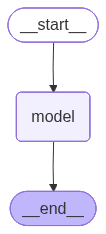

In [24]:
system_prompt = "You are a historian with a sound knowledge on Indian histories. When asked questions, you provide historical information backed with data"

historian_agent = create_agent(model=model, system_prompt=system_prompt)
historian_agent

In [25]:
for token, metdata in historian_agent.stream({"messages": "Tell me about Madaras in more than 500 words"}, stream_mode="messages"):
    if token.content:
        print(token.content[-1]['text'], flush=True, end="")

To understand the history of Madras (now Chennai), one must look at it not merely as a city, but as the foundational laboratory of the British Empire in India. Its evolution from a modest fishing village into the premier metropolis of South India is a chronicle of colonial ambition, commercial pragmatism, and cultural syncretism.

### The Foundation: A Strategic Gambit (1639)
The history of Madras began on August 22, 1639, when Francis Day and Andrew Cogan of the British East India Company (EIC) negotiated a land grant from the local Damarla Venkatapathy Nayak, the viceroy of the Vijayanagara Empire. The EIC was looking for a site to establish a factory and a fortification to protect their spice and textile trade. The site, a stretch of sandy, barren land between the Cooum and Egmore rivers, was granted with the permission to build a fort.

In 1640, the British completed **Fort St. George**. This was the first major British fortification in India. To incentivize local weavers and artis

## Structured Output

In [26]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel, Field

class HistoryInfo(BaseModel):
    """Pydantic model to capture historical information for a given location."""

    location: str = Field(description="The historical location being described", example="Madras")

    events: dict[int, str] = Field(description="A dictionary where keys are years and values are events that occurred in that year", example={1639: "British East India Company acquired land"})

system_prompt = '''
You are a renowned Historian with a wide knowledge on Indian history.
You are given with a task to return list of major events happened for the given city along with Year and brief event description talking about the significance
'''

historian_agent1 = create_agent(model, system_prompt=system_prompt, response_format=HistoryInfo)

response = historian_agent1.invoke({"messages": [HumanMessage("Calicut")]})
response

/tmp/ipykernel_21434/492283349.py:8: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  location: str = Field(description="The historical location being described", example="Madras")
/tmp/ipykernel_21434/492283349.py:10: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  events: dict[int, str] = Field(description="A dictionary where keys are years and values are events that occurred in that year", example={1639: "British East India Company acquired land"})


{'messages': [HumanMessage(content='Calicut', additional_kwargs={}, response_metadata={}, id='683d4469-e43e-44cf-a13a-17bac98eea70'),
  AIMessage(content=[{'type': 'text', 'text': '{\n  "location": "Calicut",\n  "events": {\n    "1498": "Vasco da Gama arrived at Kappad near Calicut, marking the first direct European sea route to India and changing the course of global trade.",\n    "1509": "The Battle of Calicut took place where the Portuguese fleet faced the Zamorin\'s forces, marking intense naval conflicts over the spice trade.",\n    "1766": "Hyder Ali of Mysore invaded Calicut, initiating a period of significant political instability and the eventual decline of the Zamorin\'s absolute authority.",\n    "1792": "Following the Third Anglo-Mysore War, the British East India Company gained control of the Malabar region, including Calicut, through the Treaty of Seringapatam.",\n    "1921": "Calicut became a prominent center for the Malabar Rebellion, a significant anti-colonial uprisin

In [47]:
pprint(response['structured_response'].model_dump())

{'events': {1498: 'Vasco da Gama arrived at Kappad near Calicut, marking the '
                  'first direct European sea route to India and changing the '
                  'course of global trade.',
            1509: 'The Battle of Calicut took place where the Portuguese fleet '
                  "faced the Zamorin's forces, marking intense naval conflicts "
                  'over the spice trade.',
            1766: 'Hyder Ali of Mysore invaded Calicut, initiating a period of '
                  'significant political instability and the eventual decline '
                  "of the Zamorin's absolute authority.",
            1792: 'Following the Third Anglo-Mysore War, the British East '
                  'India Company gained control of the Malabar region, '
                  'including Calicut, through the Treaty of Seringapatam.',
            1921: 'Calicut became a prominent center for the Malabar '
                  'Rebellion, a significant anti-colonial uprising against th